In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
%gui qt

In [3]:
from pylab import *

In [4]:
from slm import LCOS
import slm

print("slm", slm.__version__)

In [5]:
from slm.utilities.displays import display_discovery

In [6]:
display_discovery()

{0: {'name': 'Odyssey G93SD', 'width': 5120, 'height': 1440, 'x': 0, 'y': 0},
 1: {'name': '\\\\.\\DISPLAY1',
  'width': 1920,
  'height': 1152,
  'x': 5120,
  'y': 0}}

In [7]:
slm = LCOS(screen = 'meadowlark')



Target slm "meadowlark" found with resolution 1920x1152
Display size (Y,X):  1152 1920


# Simple Holography Gui

In [8]:
from slm.ui.simpleholography.pistoning import PistoningWidget

pistoning_gui = PistoningWidget(slm)
pistoning_gui.show()

In [9]:
pistoning_gui._region_controls['right'].spin.setValue(np.pi/2)

# Mod Mux Gui

In [9]:
from slm.ui.ModMux import ModMuxWidget
modmux_gui = ModMuxWidget(slm)
modmux_gui.show()

# Test ModMux

In [9]:
# Test ModMux
from pathlib import Path
import sys
repo = Path.cwd()
if not (repo / "pyLCOS.py").exists():
    repo = repo.parent  # .../SLM
zernikes_dir = repo.parent.parent / "algorithms" / "zernikes"
if str(zernikes_dir) not in sys.path:
    sys.path.insert(0, str(zernikes_dir))


In [10]:
from zernikes import Zernikes
from zernike_catalog import MODE_NAMES

In [11]:
z = Zernikes(
    max_zernike_radial_number=6,
    mask_size_x_in_pixels=960,
    mask_size_y_in_pixels=960,
    aperture_diameter_in_m=7.5e-3,   # match pyLCOS defaults
    SLM_pixel_size_in_um=9.2e-6
)

In [12]:
for idx,(key, item) in enumerate(MODE_NAMES.items()):
    print(idx,'-', item, key)

0 - Piston (0, 0)
1 - Tilt X (1, -1)
2 - Tilt Y (1, 1)
3 - Astigmatism 45° (2, -2)
4 - Defocus (2, 0)
5 - Astigmatism 0°/90° (2, 2)
6 - Trefoil Y (3, -3)
7 - Coma Y (3, -1)
8 - Coma X (3, 1)
9 - Trefoil X (3, 3)
10 - Tetrafoil Y (4, -4)
11 - Secondary astigmatism 45° (4, -2)
12 - Spherical (4, 0)
13 - Secondary astigmatism 0°/90° (4, 2)
14 - Tetrafoil X (4, 4)


In [13]:

z.tilt_x_h = 0
z.tilt_y_h = 10

z.w_v[4] = 10
z.calculate_znk_phase_mask(restore_coefs=False)

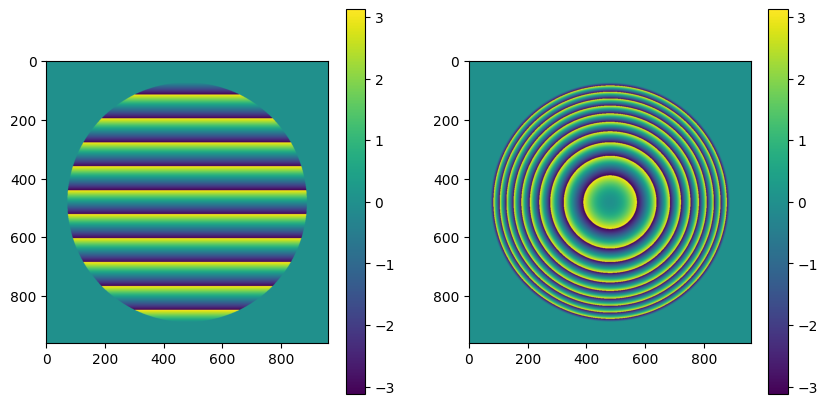

In [14]:
fig, ax = subplots(1,2, figsize = (10,5))
h_mask = z.znk_phase_h
v_mask = z.znk_phase_v
im = ax[0].imshow(h_mask)
cbar = fig.colorbar(im, ax = ax[0])
ax[1].imshow(v_mask)
cbar = fig.colorbar(im, ax = ax[1])


In [16]:
table = z.generate_table()

In [20]:
slm.ModMuxMask.H.zernike = h_mask
slm.ModMuxMask.V.zernike = v_mask

In [103]:
slm.ModMuxMask.H.zernikes_enabled = 1
slm.setmask(pol = 'HV')

In [104]:
modmux_gui._update_preview()

In [97]:
slm.resetAttenuation()

In [105]:
modmux_gui.refresh_gui_state()

In [45]:
modmux_gui._disable_user_interface()

In [76]:
modmux_gui._enable_user_interface()

In [90]:
slm.setmask(pol = 'HV')

In [101]:
modmux_gui.apply_and_display()

# From old

In [44]:
import pyLCOS

In [45]:
import sys
win_home_module_path = r'C:\\LAB\\Coding\\Python\\MODULES'
sys.path.insert(1, win_home_module_path)
import mark_lib as mkl
import holography as holo
t = mkl.times

ModuleNotFoundError: No module named 'mark_lib'

In [ ]:
slm = pyLCOS.LCOS(screen=1)

Display size (Y,X):  1440 5120


ValueError: could not broadcast input array from shape (800,800) into shape (561,2560)

### IMPORT ZERNIKES MODULE AND CREATE THEM FROM MODELAB

In [46]:
z = holo.Zernikes(max_zernike_radial_number=6, mask_size_x_in_pixels=960, mask_size_y_in_pixels=960)

NameError: name 'holo' is not defined

In [ ]:
print(z.h_mask_center_x, z.h_mask_center_y, z.v_mask_center_x, z.v_mask_center_y)

586 537 1398 535


### SOME MODES MASKS

In [15]:
import h5py
import hdf5storage
path_to_modes = "C:\LAB\Coding\Python\Data\SLM_MASKS\MODELIBRARY_Fibre_GradedIndex_ARCoated_17_1300nm_25mm_lens_SMFside_w0slm_1.93mm_8mm_lens_MMFside_core_diameter_62.5um_maxMG_22_mfd_12.2um_Crosstalk_25dB_OPTI_v3.mat"
data = hdf5storage.loadmat(path_to_modes) # it loads data as a dictionary
data.keys()
modesMasks = angle(data['ILLUMINATION'][:,1024//2-480:1024//2+480,1024//2-480:1024//2+480,])
modesMasks.shape

(253, 960, 960)

### CREATE LCOS OBJECT (PASSING ZERNIKES)

In [8]:
slm = pyLCOS.LCOS(screen=1, mask_size=(960,960), zernikeH = angle(z.field_h), zernikeV = angle(z.field_v)) #Zernike provided as a complex field

Display size (Y,X):  1152 1920


In [9]:
slm.screen

<function LCOS.screen>

In [9]:
t.tic()
Hcenter = [586,537]
Vcenter = [1398,535]
slm.setCenters(Hcenter,Vcenter)
t.toc()

Elapsed time =  0.05190873146057129


0.05190873146057129

In [10]:
slm.setCenters(Hcenter,Vcenter)
t.toc()

Elapsed time =  2.845201253890991


2.845201253890991

### BUNCH OF MASK SETTING AND SETTING DISPLAY MASK

In [23]:
slm.mask_specs['H']['att_enabled'] = 0
slm.mask_specs['H']['attWeight'] = 0
slm.mask_specs['V']['att_enabled'] = 0
slm.mask_specs['V']['attWeight'] = 0
slm.mask_specs['H']['pattern'] = modesMasks[0]
slm.mask_specs['V']['pattern'] = modesMasks[2]

slm.patternEnabled = 1
slm.zernikesEnabled = 1

slm.setmask(pol = 'H')
slm.refreshfreq #check refreshrate.

13.36919443213729

## OTHER STUFF (DEBUGGING)

In [33]:
for i in range(6):
    #t.tic()
    slm.mask_specs['H']['pattern'] = modesMasks[i]
    slm.mask_specs['V']['pattern'] = modesMasks[5-i]
    slm.setmask(pol = 'HV')
    #t.toc()
    

In [10]:
slm.mask_specs['V']['centers'] = [1397,535]

In [ ]:
slm.offset_center = 0
slm._defineCenters()
slm._calcApertures()
slm.setmask(pol = 'V')
print(slm.Hcenter, slm.Vcenter)


[586, 614] [1397, 616]


In [112]:
def binarycheckboard(width, height, spatial_frequency, scale=1, offset = False ,pol = 'HV'):
    y = np.arange(height, dtype = np.float64)#linspace(0,2*pi,1080)
    x = np.arange(width, dtype = np.float64)
    X,Y = np.meshgrid(x,y)
    
    GY = (((Y*spatial_frequency)%(1.0)>=.5)*scale).astype(np.float64)
    GX = (((X*spatial_frequency)%(1.0)>=.5)*scale).astype(np.float64)
     
    chBoard = abs(GX - GY)
    
    if offset == True:
        offset = scale/2
        chBoard -= offset
    
    if pol == 'H':
        chBoard[:,int(x.max()//2):-1] = 0
    elif pol == 'V':
        chBoard[:,0:int(x.max()//2)] = 0

    return(chBoard,GX,GY)

In [113]:
checker, GX, GY = binarycheckboard(960, 960, spatial_frequency = 1/100, scale=1, offset = True, pol = 'HV')

(<matplotlib.image.AxesImage at 0x23acb6064c8>,
 <matplotlib.colorbar.Colorbar at 0x23acb606088>)

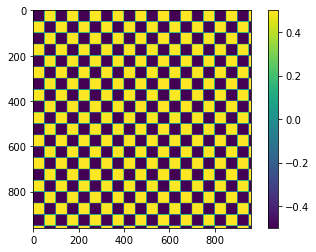

In [114]:
imshow(checker), colorbar()

(<matplotlib.image.AxesImage at 0x23acb517608>,
 <matplotlib.colorbar.Colorbar at 0x23acb469488>)

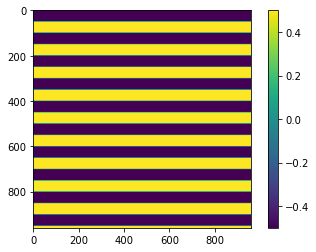

In [111]:
imshow(GY),colorbar()

In [106]:
GY

array([[-0.5, -0.5, -0.5, ..., -0.5, -0.5, -0.5],
       [-0.5, -0.5, -0.5, ..., -0.5, -0.5, -0.5],
       [-0.5, -0.5, -0.5, ..., -0.5, -0.5, -0.5],
       ...,
       [ 0.5,  0.5,  0.5, ...,  0.5,  0.5,  0.5],
       [ 0.5,  0.5,  0.5, ...,  0.5,  0.5,  0.5],
       [ 0.5,  0.5,  0.5, ...,  0.5,  0.5,  0.5]])